In [1]:
import pickle
import numpy as np

In [2]:
X = pickle.load(open('X.pkl', 'rb'))
Y = pickle.load(open('Y.pkl', 'rb'))

In [3]:
Y = Y.reshape(len(Y),1)
X=X/255.0

In [4]:
X.shape

(20000, 60, 60, 3)

In [5]:
Y.shape

(20000, 1)

In [6]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

In [7]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation = 'relu',input_shape = X.shape[1:]))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(32, (3,3), activation = 'relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(64, input_shape = X.shape[1:], activation = 'relu'))

model.add(Dense(1, activation = 'sigmoid'))

C:\Users\karti\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\karti\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [12]:
history = model.fit(
    X_train_val, y_train_val,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.5346 - loss: 0.6851 - val_accuracy: 0.6994 - val_loss: 0.5741
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.7238 - loss: 0.5484 - val_accuracy: 0.7519 - val_loss: 0.5115
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.7765 - loss: 0.4771 - val_accuracy: 0.7484 - val_loss: 0.5095
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.7991 - loss: 0.4299 - val_accuracy: 0.7709 - val_loss: 0.4761
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.8130 - loss: 0.4038 - val_accuracy: 0.7741 - val_loss: 0.4852
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8470 - loss: 0.3494 - val_accuracy: 0.7725 - val_loss: 0.4846
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8726 - loss: 0.3027 - val_accuracy: 0.7809 - val_loss: 0.4711
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8935 - loss: 0.2588 - val_acc

In [13]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, batch_size=32)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7792 - loss: 0.5671 
Test Loss: 0.5728335380554199
Test Accuracy: 0.7787500023841858


In [14]:
import time

time.time()

1736538986.1263814

In [15]:
type(1581428129.5990093)

float

In [17]:

import random
import matplotlib.pyplot as plt 

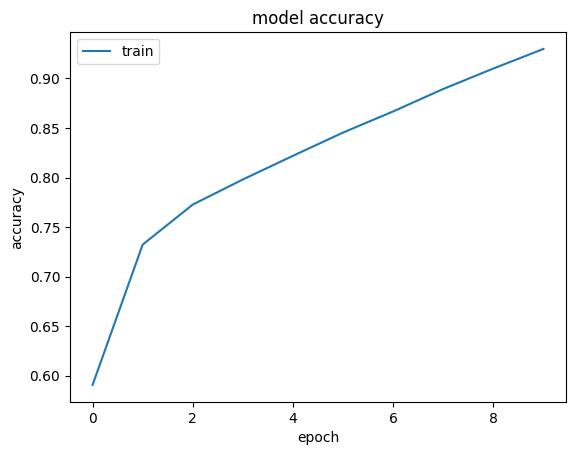

In [18]:
plt.plot(history.history['accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train'],loc='upper left')
plt.show()

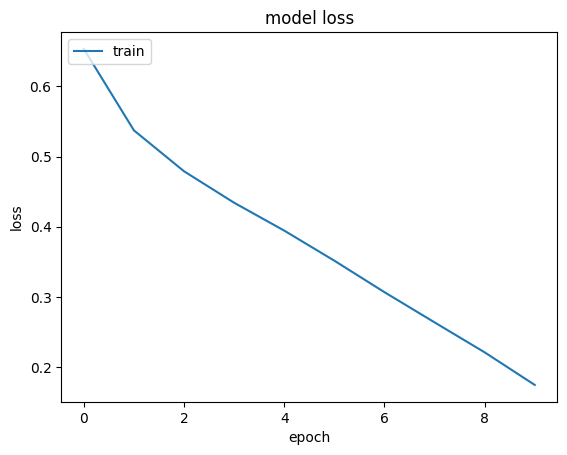

In [19]:
plt.plot(history.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train'],loc='upper left')
plt.show()

In [20]:
model.save("Training_model.keras")

In [21]:
pickle.dump(X_test, open('X_test.pkl','wb'))
pickle.dump(y_test, open('Y_test.pkl','wb'))

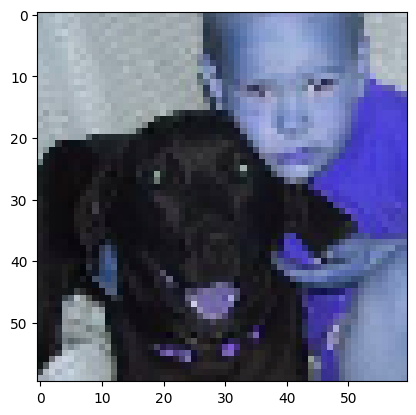

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
this is the picture of a :  dog


In [22]:
idx2=random.randint(0,len(y_test))
plt.imshow(X_test[idx2, :])
plt.show()

Y_pred =model.predict(X_test[idx2, :].reshape(1,60,60,3))
Y_pred = Y_pred > 0.5

if(Y_pred==0):
    pred='cat'
else:
    pred = 'dog'
print("this is the picture of a : ",pred)